<a href="https://colab.research.google.com/github/Aleem-mja/DeepLearning-Project-SLIIT-SE4050/blob/IT22339324/IT22339324.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Review Sentiment Analysis using Bidirectional LSTM

This shows sentiment analysis on movie reviews.  
It includes steps for:  

- Text preprocessing (cleaning, tokenization, lemmatization, stopword removal)  
- Building a Bidirectional LSTM model  
- Training and evaluating the model on test data  
- Visualizing accuracy, loss, and confusion matrix  
- Predicting sentiment for custom movie reviews


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import nltk, re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
# --- NLTK setup ---
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# --- Extract dataset from Drive ---
import tarfile
dataset_path = '/content/drive/MyDrive/aclImdb_v1.tar.gz'
extract_path = '/content/aclImdb'
if not os.path.exists(extract_path):
    with tarfile.open(dataset_path) as tar:
        tar.extractall(path='/content')
print("Dataset extracted.")

/tmp/ipython-input-2368647180.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/content')


Dataset extracted.


In [5]:
# --- Load IMDB data ---
def load_data_from_folder(folder):
    data = []
    for label in ['pos', 'neg']:
        path = os.path.join(folder, label)
        for file in os.listdir(path):
            with open(os.path.join(path, file), encoding='utf8') as f:
                data.append([f.read(), 1 if label == 'pos' else 0])
    return pd.DataFrame(data, columns=['text', 'label'])

train_data = load_data_from_folder('/content/aclImdb/train')
test_data = load_data_from_folder('/content/aclImdb/test')

In [6]:
# Display a sample of positive reviews (label == 1)
print("Positive reviews sample:")
print(train_data[train_data['label'] == 1].sample(5))  # Display 5 random positive reviews

# Display a sample of negative reviews (label == 0)
print("\nNegative reviews sample:")
print(train_data[train_data['label'] == 0].sample(5))  # Display 5 random negative reviews

Positive reviews sample:
                                                    text  label
3432   I once lived with a roommate who attempted sui...      1
7626   So, finally I know it exists. Along with the o...      1
11074  After CITIZEN KANE in 1941, Hollywood executiv...      1
5298   Dwight Frye steals the show in this one as a f...      1
29     This is not the stuff of soap-operas but the s...      1

Negative reviews sample:
                                                    text  label
15006  This movie has no plot and no focus. Yes, it's...      0
24926  Schlocky '70s horror films...ya gotta love 'em...      0
18204  A battleship is sinking... Its survivors, hang...      0
22277  As soon as it hits a screen, it destroys all i...      0
22018  Movie about a small town with equal numbers of...      0


### Dataset Details

**Dataset:** IMDB Movie Reviews Dataset (aclImdb)  
**Source:** [IMDB Large Movie Review Dataset by Maas et al.](https://ai.stanford.edu/~amaas/data/sentiment/)  
**Type:** Supervised Sentiment Classification (binary: positive/negative)

**Attributes:**
- Each sample: a movie review (text)  
- Label: 0 = Negative, 1 = Positive  
- Data size: 50,000 reviews total  
  - 25,000 for training  
  - 25,000 for testing  
- Balanced dataset: 50% positive, 50% negative  
- Average review length: ~230 words  

This dataset is widely used in NLP for benchmarking sentiment classification models.  
It provides a real-world example of natural, noisy text, making it suitable for deep learning approaches.



/tmp/ipython-input-3497268499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_data, palette='pastel')


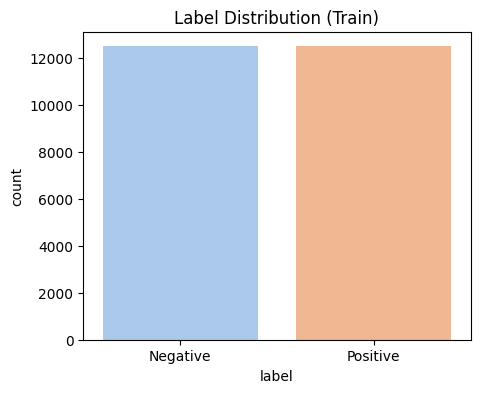

In [7]:
# --- Label distribution plot ---
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=train_data, palette='pastel')
plt.title('Label Distribution (Train)')
plt.xticks([0,1], ['Negative','Positive'])
plt.show()

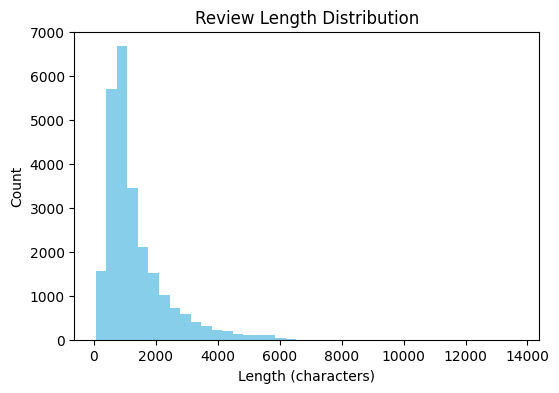

In [8]:
# --- Review length distribution ---
train_data['review_length'] = train_data['text'].apply(len)
plt.figure(figsize=(6,4))
plt.hist(train_data['review_length'], bins=40, color='skyblue')
plt.title('Review Length Distribution')
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.show()

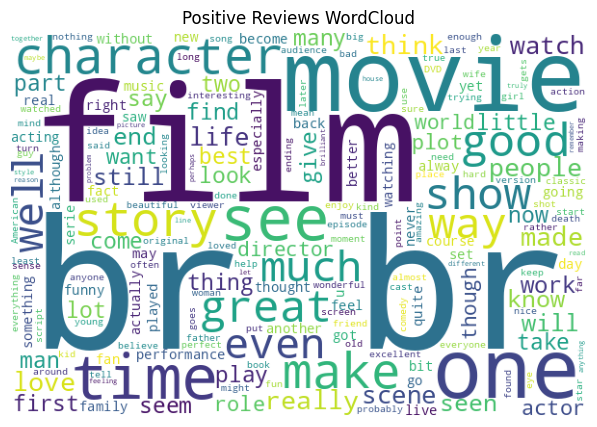

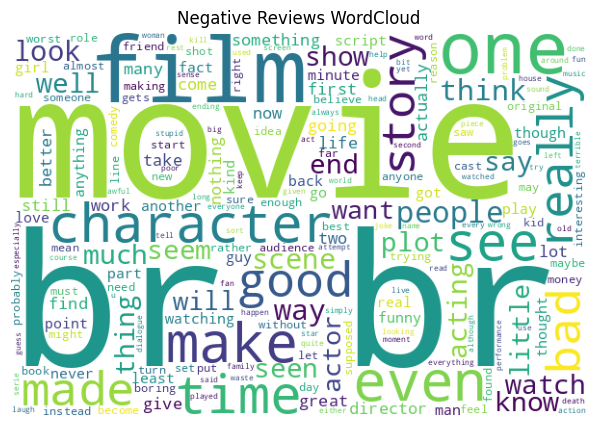

In [9]:
# --- WordClouds ---
pos_text = " ".join(train_data[train_data.label==1]['text'])
neg_text = " ".join(train_data[train_data.label==0]['text'])
wc = WordCloud(width=600, height=400, background_color='white', max_words=200)

plt.figure(figsize=(8,5))
plt.imshow(wc.generate(pos_text))
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

plt.figure(figsize=(8,5))
plt.imshow(wc.generate(neg_text))
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()


In [10]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
# --- Text preprocessing ---
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

train_data['clean_text'] = train_data['text'].apply(preprocess_text)
test_data['clean_text'] = test_data['text'].apply(preprocess_text)

In [12]:
# --- Tokenize and pad sequences ---
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_NB_WORDS = 10000
MAX_SEQUENCE_LENGTH = 200

tokenizer = Tokenizer(num_words=MAX_NB_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_data['clean_text'])
vocab_size = min(MAX_NB_WORDS, len(tokenizer.word_index)+1)

X_train = pad_sequences(tokenizer.texts_to_sequences(train_data['clean_text']),
                        maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data['clean_text']),
                       maxlen=MAX_SEQUENCE_LENGTH, padding='post')

y_train = train_data['label'].values
y_test = test_data['label'].values

### Why Bidirectional LSTM (BiLSTM) Was Chosen

Traditional RNNs and LSTMs process text in one direction (left to right).  
However, in natural language, understanding often depends on both past and future context.

**Ex:**  
- “The movie was *not great*.” → The meaning of “not” changes the sentiment of “great.”  

A **Bidirectional LSTM** reads the sequence **forward and backward**, capturing dependencies from both directions.  
This makes it particularly effective for **sentiment analysis**, where context on both sides of a word affects meaning.

**Advantages:**
- Better context understanding  
- Handles long-term dependencies  

Therefore, BiLSTM is chosen over simple LSTM for improved accuracy in text sentiment classification.


In [13]:
# --- Define the model ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Function to create the model
def make_model(vocab_size=10000, embedding_dim=100, input_length=200):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  input_length=input_length,
                  trainable=True),  # ensures it learns during training,
        Bidirectional(LSTM(128, return_sequences=False)),  # Bidirectional LSTM
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- Train/Validation split (faster and simpler) ---
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model = make_model(vocab_size=10000, embedding_dim=100, input_length=X_train.shape[1])

history = model.fit(
    X_train, y_train,
    validation_split=0.1,   # 10% for validation
    epochs=5,
    batch_size=64,
    callbacks=[es],
    verbose=1
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


352/352 ━━━━━━━━━━━━━━━━━━━━ 311s 866ms/step - accuracy: 0.7111 - loss: 0.5436 - val_accuracy: 0.8460 - val_loss: 0.3516
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 304s 863ms/step - accuracy: 0.9186 - loss: 0.2274 - val_accuracy: 0.8584 - val_loss: 0.3436
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 306s 868ms/step - accuracy: 0.9415 - loss: 0.1699 - val_accuracy: 0.8444 - val_loss: 0.4001
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 309s 878ms/step - accuracy: 0.9578 - loss: 0.1264 - val_accuracy: 0.8900 - val_loss: 0.3426
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 307s 871ms/step - accuracy: 0.9636 - loss: 0.1102 - val_accuracy: 0.8460 - val_loss: 0.6505


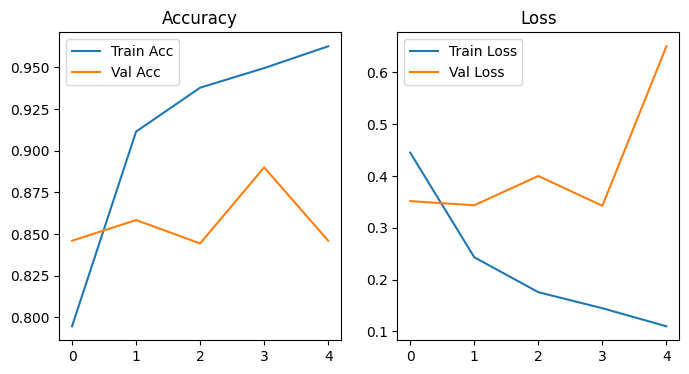

In [16]:
# Plot accuracy and loss
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [15]:
# --- Final training on full data ---
final_model = make_model()
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
final_model.fit(X_train, y_train, validation_split=0.1,
                epochs=5, batch_size=64, callbacks=[es], verbose=1)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 322s 902ms/step - accuracy: 0.7214 - loss: 0.5307 - val_accuracy: 0.8844 - val_loss: 0.2796
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 327s 929ms/step - accuracy: 0.9067 - loss: 0.2507 - val_accuracy: 0.8744 - val_loss: 0.3089
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 317s 900ms/step - accuracy: 0.9418 - loss: 0.1649 - val_accuracy: 0.8832 - val_loss: 0.4586


###  Final Training with Early Stopping

After validating the model architecture and performance, retrain the **Bidirectional LSTM (BiLSTM)** model on the **full training dataset**.  
The **EarlyStopping** callback is used again here for the same reason as before ,to automatically stop training when the **validation loss** no longer improves.

This ensures that:
- The model does **not overfit** the data.
- Training **stops at the optimal epoch**, saving time and resources.
- The **best weights** (from the epoch with lowest validation loss) are automatically restored.

Although this may cause the model to stop before completing all epochs, it actually helps us obtain the **most generalizable and best performing version** of the final model.


In [17]:
# --- Evaluate on test set ---
y_pred = (final_model.predict(X_test) > 0.5).astype('int')
# Generate classification report as a dictionary
report = classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive'],
    output_dict=True
)

# Print formatted report (4 decimal places)
print("---- BiLSTM Model Performance ----")
print(f"Accuracy       : {report['accuracy']:.4f}")
print(f"Precision (avg): {report['weighted avg']['precision']:.4f}")
print(f"Recall (avg)   : {report['weighted avg']['recall']:.4f}")
print(f"F1-Score (avg) : {report['weighted avg']['f1-score']:.4f}")

# --- Validation loss from training history ---
val_loss = min(history.history['val_loss'])
print(f"Validation Loss: {val_loss:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 147s 187ms/step
---- BiLSTM Model Performance ----
Accuracy       : 0.8561
Precision (avg): 0.8573
Recall (avg)   : 0.8561
F1-Score (avg) : 0.8560
Validation Loss: 0.3426


In [18]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.85608


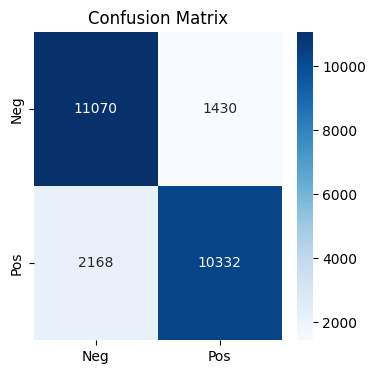

In [19]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.title('Confusion Matrix')
plt.show()

In [20]:
# --- Save and reload ---
final_model.save('sentiment_analysis_model.keras')
from tensorflow.keras.models import load_model
loaded_model = load_model('sentiment_analysis_model.keras')

In [21]:
# --- Predict on custom text ---
def prepare_input_for_model(text):
    text = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
    return pad

sample = "This movie was amazing! The storyline and acting were brilliant."
pred = (loaded_model.predict(prepare_input_for_model(sample)) > 0.5).astype('int')[0][0]
print("Prediction:", "Positive" if pred==1 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
Prediction: Positive


In [22]:
sample_neg = "This movie was terrible. The plot was boring and the acting was awful."
pred_neg = (loaded_model.predict(prepare_input_for_model(sample_neg)) > 0.5).astype('int')[0][0]
print("Prediction:", "Positive" if pred_neg==1 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Prediction: Negative


### Results Analysis

**Model Evaluation Metrics:**
- Accuracy: (show value printed above)
- Precision, Recall, F1-Score (see classification report)
- Confusion Matrix (visualized above)

**Interpretation:**
- High accuracy indicates the model correctly classifies most reviews.
- Balanced precision and recall show it performs equally well on positive and negative samples.
- Misclassifications usually occur in reviews with mixed or subtle opinions.



